In [ ]:
"""
What is Streaming

In LLMs, streaming means the model starts sending tokens (words) as soon as they're generated, instead of waiting for the entire response to be ready before returning it.
Why Streaming
1. Faster response time - low drop-off rates
2. Mimics human like conversation (Builds trust, feels alive and keeps the user engaged) 3. Important for Multi-modal Uls
4. Better UX for long output such as code
5. You can cancel midway saving tokens
6. You can interleave UI updates, e.g., show "thinking...", show tool results

| Mode         | Purpose                               |
| ------------ | ------------------------------------- |
| `"updates"`  | Stream node outputs                   |
| `"values"`   | Stream complete state after each node |
| `"messages"` | Stream LLM tokens/messages            |
| `"debug"`    | Detailed graph execution events       |


"""

In [8]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_community.chat_models import ChatOllama

c:\Users\Swati\llm_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model = ChatOllama(model="llama3", temparature=1.5)

C:\Users\Swati\AppData\Local\Temp\ipykernel_22308\3307222411.py:1: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  model = ChatOllama(model="llama3", temparature=1.5)


In [5]:
class StremingState(TypedDict):
    question: str
    answer: str

In [10]:
def answer_from_llm(state: StremingState):
    user_question = state['question']

    llm_answer = model.invoke(user_question).content
    state['question'] = user_question
    return {"answer": llm_answer}


In [ ]:
graph = StateGraph(StremingState)

graph.add_node('llm_answer', answer_from_llm)

graph.add_edge(START, 'llm_answer')
graph.add_edge('llm_answer', END)

workflow = graph.compile()

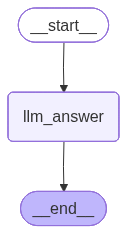

In [14]:
workflow

In [18]:
initial_state = {"question": "What is the capital of France?"}
# workflow.invoke(initial_state, {"configurable": {"thread_id": "1"}})
for i in workflow.stream(initial_state, stream_mode='messages'):
    print("i is ", i)

i is  (AIMessageChunk(content='The', additional_kwargs={}, response_metadata={}, id='lc_run--019ed059-0d0a-7a42-911d-5baaefcea6c5', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'ls_integration': 'langchain_chat_model', 'langgraph_step': 1, 'langgraph_node': 'llm_answer', 'langgraph_triggers': ('branch:to:llm_answer',), 'langgraph_path': ('__pregel_pull', 'llm_answer'), 'langgraph_checkpoint_ns': 'llm_answer:7fe44b6b-4aec-bc48-54fd-089386e242bc', 'checkpoint_ns': 'llm_answer:7fe44b6b-4aec-bc48-54fd-089386e242bc', 'ls_provider': 'ollama', 'ls_model_name': 'llama3', 'ls_model_type': 'chat', 'ls_temperature': None})
i is  (AIMessageChunk(content=' capital', additional_kwargs={}, response_metadata={}, id='lc_run--019ed059-0d0a-7a42-911d-5baaefcea6c5', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'ls_integration': 'langchain_chat_model', 'langgraph_step': 1, 'langgraph_node': 'llm_answer', 'langgraph_triggers': ('branch:to:llm_answer',), 'langgraph_path': ('__

In [ ]:
# streaming token-by-token.
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3",
    streaming=True
)

initial_state = {"question": "What is the capital of France?"}


def answer_from_llm(state: StremingState):
    user_question = state['question']

    llm_answer = llm.invoke(user_question).content
    state['question'] = user_question
    return {"answer": llm_answer}


graph = StateGraph(StremingState)

graph.add_node('llm_answer', answer_from_llm)

graph.add_edge(START, 'llm_answer')
graph.add_edge('llm_answer', END)

workflow = graph.compile()

for chunk, metadata  in workflow.stream(initial_state, stream_mode="messages"):
    #chunk is dict with keys: content, node_id, state, is_final
    print(chunk.content, end="", flush=True)
    
'''
for chunk  in workflow.stream(initial_state, stream_mode="updates"):
    # chunk is dict with keys: content, node_id, state, is_final
    print(chunk, end="", flush=True) # {'llm_answer': {'answer': 'The capital of France is Paris.'}}
'''


The capital of France is Paris.

'\nfor chunk  in workflow.stream(initial_state, stream_mode="updates"):\n    # chunk is dict with keys: content, node_id, state, is_final\n    print(chunk, end="", flush=True) # {\'llm_answer\': {\'answer\': \'The capital of France is Paris.\'}}\n'